In [2]:
# ============================================================
# CELL 1 — SET PATH & LOAD NI‑DAQ TTL DATA
# ============================================================

import numpy as np
import os

# ============================================================
# TUNABLE PARAMETERS
# ============================================================

ni_folder = r"D:\Kevin\2026-03-05_09-27-03\Record Node 106\experiment2\recording1\events\NI-DAQmx-105.PXIe-6341\TTL"  ######################################################################################################################################################################
# Path to NI‑DAQ TTL folder

# ============================================================
# LOAD TTL FILES
# ============================================================

print("Using NI folder:")
print(ni_folder)

timestamps_path = os.path.join(ni_folder, "timestamps.npy")
states_path     = os.path.join(ni_folder, "states.npy")
full_words_path = os.path.join(ni_folder, "full_words.npy")

if not os.path.exists(full_words_path):
    print("❌ TTL files not found")
else:
    timestamps_ni = np.load(timestamps_path)
    states_ni     = np.load(states_path)
    full_words_ni = np.load(full_words_path)

    print("✅ TTL data loaded")
    print("Samples:", len(full_words_ni))


Using NI folder:
D:\Kevin\2026-03-05_09-27-03\Record Node 106\experiment2\recording1\events\NI-DAQmx-105.PXIe-6341\TTL
✅ TTL data loaded
Samples: 665277


Rising edges: 3729
Falling edges: 3729
First rising edge at (s): 5.2508

IPI stats:
Mean: 1.000105123390558
Std: 1.2022086112106547e-05


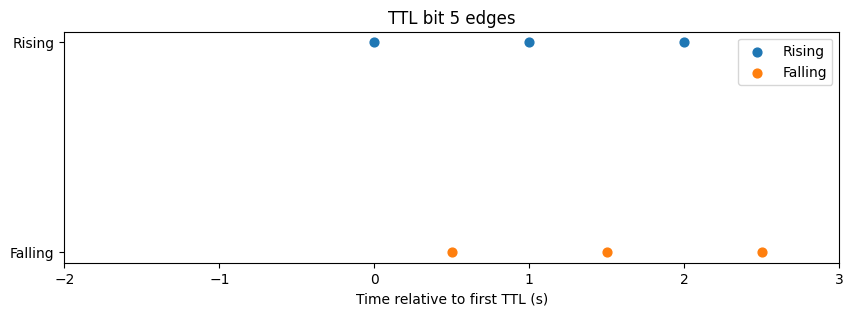

In [3]:
# ============================================================
# CELL 2 — TTL DETECTION & SINGLE‑EVENT VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# TUNABLE PARAMETERS
# ============================================================

bit = 5            ################################################################################################################################################################################################################
window_pre = 2      ################################################################################################################################################################################################################
window_post = 3     ################################################################################################################################################################################################################
# TTL bit to inspect and window around first event

# ============================================================
# EDGE DETECTION
# ============================================================

mask = 1 << bit
bit_on = (full_words_ni & mask) > 0

bit_on_prev = np.roll(bit_on, 1)
bit_on_prev[0] = False

rising_idx  = (~bit_on_prev) & (bit_on)
falling_idx = (bit_on_prev) & (~bit_on)

rising_times  = timestamps_ni[rising_idx]
falling_times = timestamps_ni[falling_idx]

# ============================================================
# BASIC INFO
# ============================================================

print("Rising edges:", len(rising_times))
print("Falling edges:", len(falling_times))

if len(rising_times) == 0:
    print("❌ No rising edges found.")

else:
    first_event = rising_times[0]
    print("First rising edge at (s):", first_event)

    if len(rising_times) > 1:
        ipi = np.diff(rising_times)
        print("\nIPI stats:")
        print("Mean:", np.mean(ipi))
        print("Std:", np.std(ipi))

    # ============================================================
    # SCATTER PLOT AROUND FIRST EVENT
    # ============================================================

    t_ref = first_event
    t0 = t_ref - window_pre
    t1 = t_ref + window_post

    mask_r = (rising_times > t0) & (rising_times < t1)
    mask_f = (falling_times > t0) & (falling_times < t1)

    rising_rel  = rising_times[mask_r] - t_ref
    falling_rel = falling_times[mask_f] - t_ref

    plt.figure(figsize=(10, 3))
    plt.scatter(rising_rel,  [1]*len(rising_rel),  s=40, label="Rising")
    plt.scatter(falling_rel, [0]*len(falling_rel), s=40, label="Falling")

    plt.yticks([0, 1], ["Falling", "Rising"])
    plt.xlabel("Time relative to first TTL (s)")
    plt.title(f"TTL bit {bit} edges")
    plt.xlim(-window_pre, window_post)
    plt.legend()
    plt.show()

    # ============================================================
    # SQUARE WAVE RECONSTRUCTION
    # ============================================================

    times  = np.concatenate([rising_times, falling_times])
    values = np.concatenate([np.ones_like(rising_times), np.zeros_like(falling_times)])

    order = np.argsort(times)
    times  = times[order]
    values = values[order]


Showing trials: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Master reference: trial 3


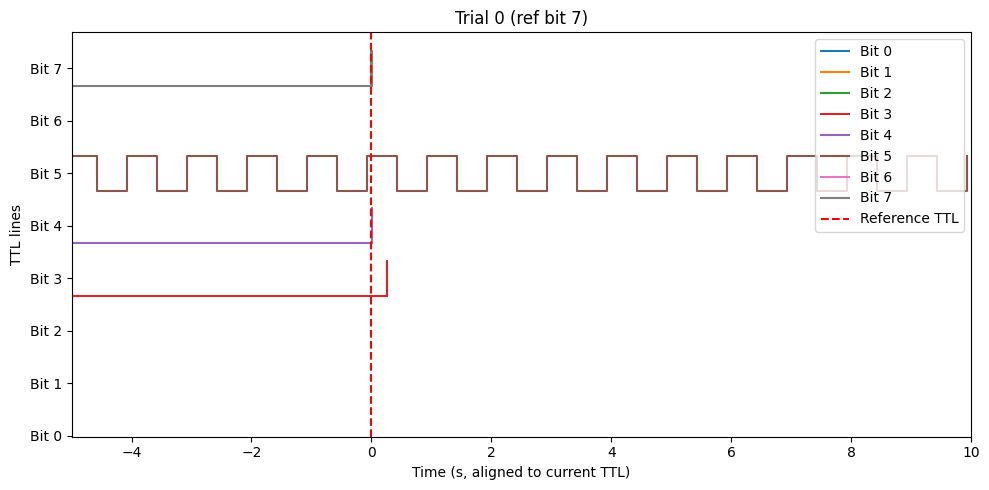

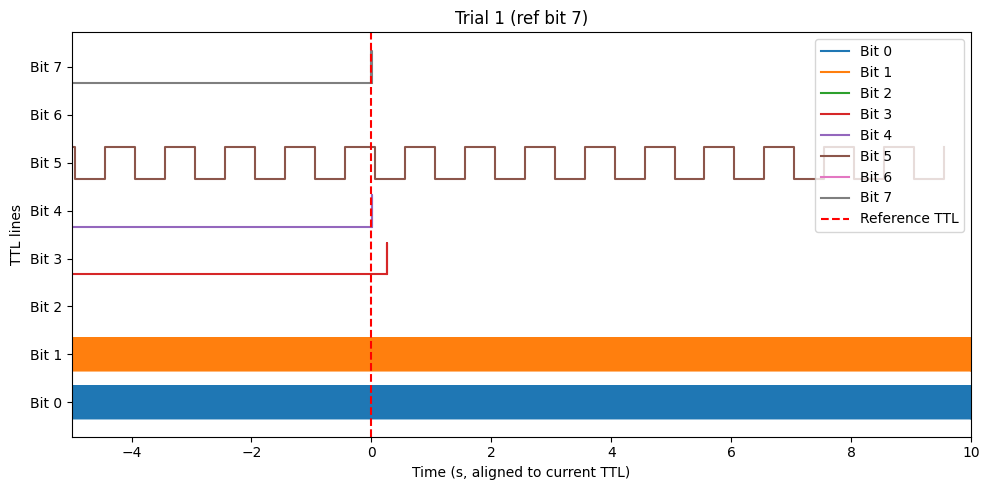

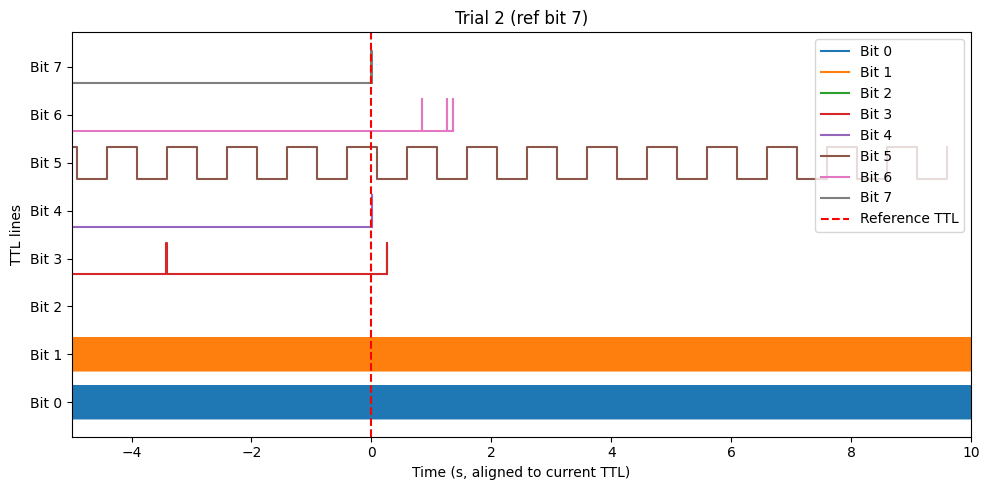

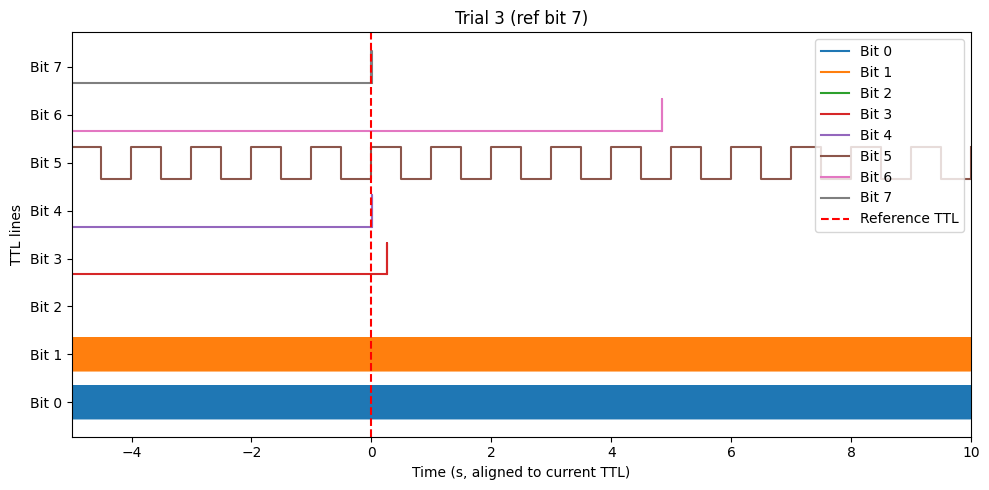

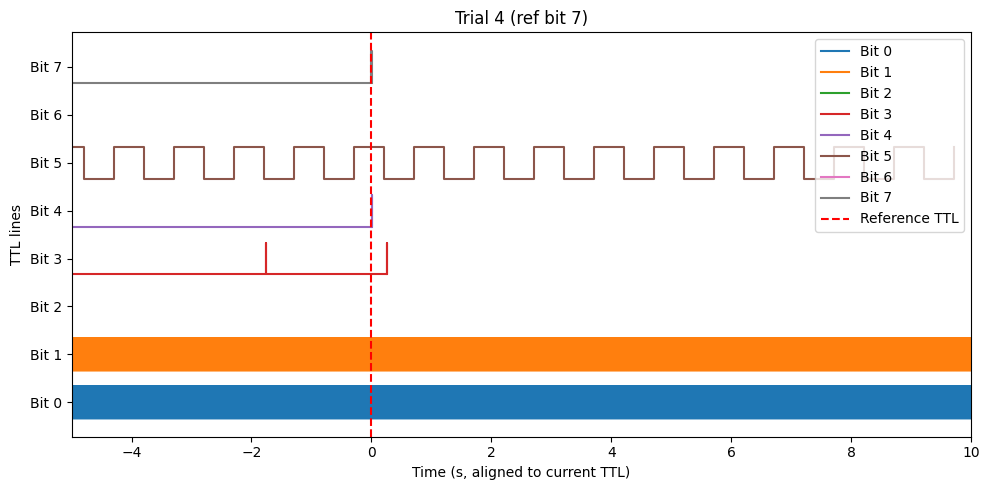

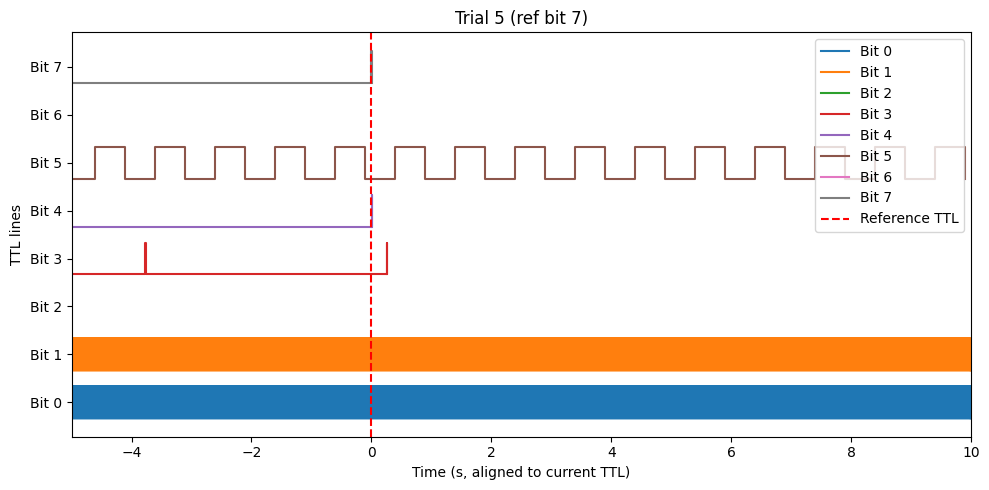

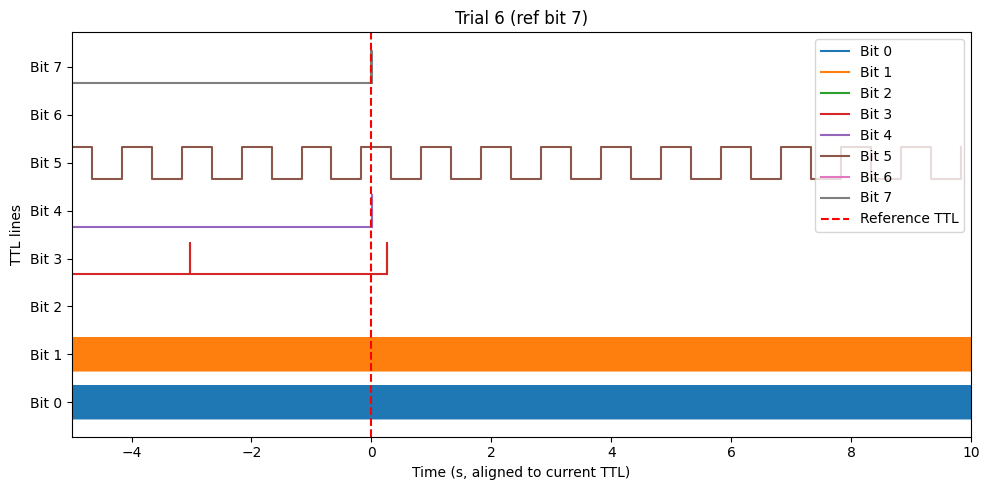

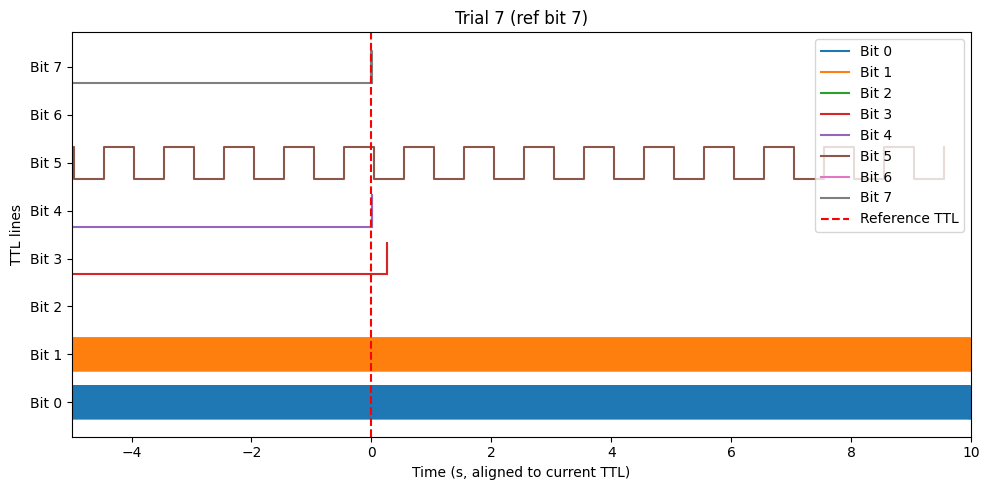

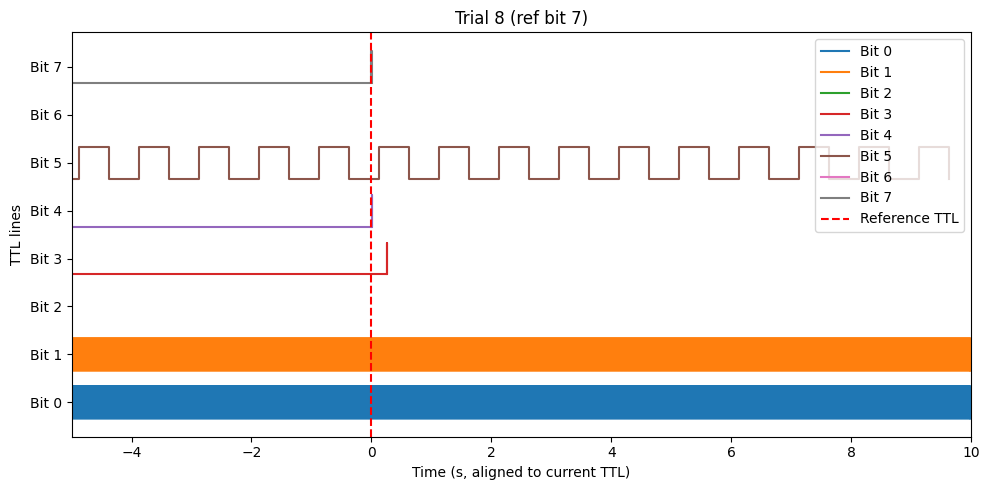

In [7]:
# ============================================================
# CELL 3 — MULTI‑TRIAL TTL VISUALIZATION (PINS 3–7)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# TUNABLE PARAMETERS
# ============================================================

bits_to_plot = [0, 1, 2, 3, 4, 5, 6, 7]     ################################################################################################
ref_bit = 7                        ################################################################################################
trial_index = 3                    ################################################################################################
n_surround = 10                     ################################################################################################
window_pre = 5                     ################################################################################################
window_post = 10                   ################################################################################################
# Bits to plot, reference bit, trial selection, and window

# ============================================================
# GET REFERENCE TTLs
# ============================================================

mask_ref = 1 << ref_bit
bit_on_ref = (full_words_ni & mask_ref) > 0

bit_on_prev_ref = np.roll(bit_on_ref, 1)
bit_on_prev_ref[0] = False

rising_ref_idx = (~bit_on_prev_ref) & (bit_on_ref)
rising_ref_times = timestamps_ni[rising_ref_idx]

n_total = len(rising_ref_times)

if n_total == 0:
    print("❌ No TTLs found on reference bit")

else:
    start = max(0, trial_index - n_surround // 2)
    end   = min(n_total, trial_index + n_surround // 2 + 1)
    trial_indices = list(range(start, end))

    print(f"Showing trials: {trial_indices}")
    print(f"Master reference: trial {trial_index}")

    # ============================================================
    # LOOP OVER SELECTED TRIALS
    # ============================================================

    for trial_i in trial_indices:

        t_ref = rising_ref_times[trial_i]
        t0 = t_ref - window_pre
        t1 = t_ref + window_post

        plt.figure(figsize=(10, 5))

        for j, bit in enumerate(bits_to_plot):

            mask = 1 << bit
            bit_on = (full_words_ni & mask) > 0

            bit_on_prev = np.roll(bit_on, 1)
            bit_on_prev[0] = False

            rising_idx  = (~bit_on_prev) & (bit_on)
            falling_idx = (bit_on_prev) & (~bit_on)

            rising_times  = timestamps_ni[rising_idx]
            falling_times = timestamps_ni[falling_idx]

            times  = np.concatenate([rising_times, falling_times])
            values = np.concatenate([np.ones_like(rising_times), np.zeros_like(falling_times)])

            order = np.argsort(times)
            times  = times[order]
            values = values[order]

            mask_window = (times > t0) & (times < t1)
            times_w  = times[mask_window]
            values_w = values[mask_window]

            prev_state = 0
            earlier = times < t0
            if np.any(earlier):
                prev_state = values[np.where(earlier)[0][-1]]

            times_plot  = np.insert(times_w, 0, t0) - t_ref
            values_plot = np.insert(values_w, 0, prev_state)

            offset = j * 1.5
            plt.step(times_plot, values_plot + offset, where='post', label=f"Bit {bit}")

        plt.axvline(0, color='red', linestyle='--', label='Reference TTL')
        plt.xlabel("Time (s, aligned to current TTL)")
        plt.ylabel("TTL lines")
        plt.title(f"Trial {trial_i} (ref bit {ref_bit})")

        plt.yticks([k * 1.5 + 0.5 for k in range(len(bits_to_plot))],
                   [f"Bit {b}" for b in bits_to_plot])

        plt.xlim(-window_pre, window_post)
        plt.legend(loc='upper right')
        plt.tight_layout()
        plt.show()


In [13]:
# ============================================================
# CELL 4 — ROBUST TTL INTEGRITY CHECK (BLOCK-AWARE)
# ============================================================

import numpy as np

# ============================================================
# TUNABLE PARAMETERS
# ============================================================

CHECK_BIT = 1                     ################################################################################################################################################################################################################################################
EXPECTED_RATE_HZ = 60            ################################################################################################################################################################################################################################################
MISSING_TTL_THRESHOLD = 60        ################################################################################################################################################################################################################################################
MIN_BLOCK_LENGTH = 100            ################################################################################################################################################################################################################################################
# TTL bit to check
# Expected TTL frequency (Hz)
# A "gap" is defined as >= this many missing TTLs
# Blocks shorter than this many TTLs are ignored

# ============================================================
# EXTRACT RISING EDGES
# ============================================================

mask = 1 << CHECK_BIT
bit_on = (full_words_ni & mask) > 0

bit_on_prev = np.roll(bit_on, 1)
bit_on_prev[0] = False

rising_idx = (~bit_on_prev) & (bit_on)
rising_times = timestamps_ni[rising_idx]

print(f"\nTTL Integrity Check — Bit {CHECK_BIT}")
print(f"Total detected rising edges: {len(rising_times)}")

if len(rising_times) < 2:
    print("❌ Not enough TTLs to evaluate integrity.")
else:

    # ============================================================
    # COMPUTE IPIs
    # ============================================================

    ipi = np.diff(rising_times)
    expected_ipi = 1.0 / EXPECTED_RATE_HZ

    # A gap is defined as >= 60 missing TTLs
    gap_threshold = expected_ipi * MISSING_TTL_THRESHOLD

    # ============================================================
    # FIND BLOCK BOUNDARIES
    # ============================================================

    gap_mask = ipi > gap_threshold
    gap_indices = np.where(gap_mask)[0]

    # Block boundaries
    block_starts = np.insert(gap_indices + 1, 0, 0)
    block_ends   = np.append(gap_indices, len(rising_times) - 1)

    print(f"\nDetected {len(block_starts)} TTL blocks (using gap threshold = {gap_threshold:.4f}s)")

    # ============================================================
    # ANALYZE EACH BLOCK
    # ============================================================

    for b, (start, end) in enumerate(zip(block_starts, block_ends)):
        block_len = end - start + 1

        if block_len < MIN_BLOCK_LENGTH:
            print(f"\nSkipping block {b} (length {block_len} < {MIN_BLOCK_LENGTH})")
            continue

        block_ipi = np.diff(rising_times[start:end+1])

        # Expected tolerance: ±10% by default
        lower = expected_ipi * 0.9
        upper = expected_ipi * 1.1

        bad_mask = (block_ipi < lower) | (block_ipi > upper)
        bad_indices = np.where(bad_mask)[0]

        print(f"\nBlock {b}:")
        print(f"  TTLs: {block_len}")
        print(f"  Start time: {rising_times[start]:.3f}s")
        print(f"  End time:   {rising_times[end]:.3f}s")
        print(f"  Mean IPI:   {np.mean(block_ipi):.5f}s")
        print(f"  Std IPI:    {np.std(block_ipi):.5f}s")

        if len(bad_indices) == 0:
            print("  ✅ Block integrity OK")
        else:
            print(f"  ❌ {len(bad_indices)} irregular intervals inside block")
            print(f"  Bad interval indices (relative to block): {bad_indices.tolist()}")



TTL Integrity Check — Bit 1
Total detected rising edges: 126639

Detected 1 TTL blocks (using gap threshold = 1.0000s)

Block 0:
  TTLs: 126639
  Start time: 192.492s
  End time:   2304.171s
  Mean IPI:   0.01667s
  Std IPI:    0.00000s
  ✅ Block integrity OK


Visualizing TTL bit 0
Total rising edges: 140559


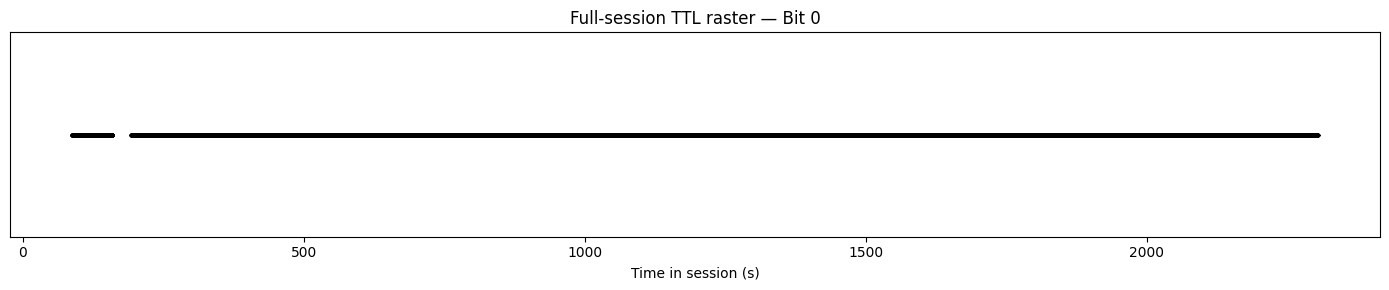

In [19]:
# ============================================================
# CELL X — FULL-SESSION TTL RASTER (BLOCK VISUALIZER)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# TUNABLE PARAMETERS
# ============================================================

VIS_BIT = 0                   ################################################################################################
DOT_SIZE = 2                    ################################################################################################
FIGSIZE = (14, 3)               ################################################################################################
# TTL bit to visualize across entire session
# Dot size for raster
# Figure size

# ============================================================
# EXTRACT RISING EDGES
# ============================================================

mask = 1 << VIS_BIT
bit_on = (full_words_ni & mask) > 0

bit_on_prev = np.roll(bit_on, 1)
bit_on_prev[0] = False

rising_idx = (~bit_on_prev) & (bit_on)
rising_times = timestamps_ni[rising_idx]

print(f"Visualizing TTL bit {VIS_BIT}")
print(f"Total rising edges: {len(rising_times)}")

# ============================================================
# PLOT FULL-SESSION RASTER
# ============================================================

plt.figure(figsize=FIGSIZE)
plt.scatter(rising_times, np.zeros_like(rising_times), s=DOT_SIZE, c='k')

plt.xlabel("Time in session (s)")
plt.yticks([])
plt.title(f"Full-session TTL raster — Bit {VIS_BIT}")

plt.tight_layout()
plt.show()
